In [8]:
!nvidia-smi

Thu Aug 27 09:39:34 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   71C    P0             33W /   70W |     687MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install mantis-tsfm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.9 MB/s eta 0:00:00


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Full CV data: (3200, 140)
Full CV labels: (3200,)
Classes: [0 1 2 3 4]
Training: (2560, 140) (2560,)
Validation: (640, 140) (640,)
Final test: (800, 140) (800,)


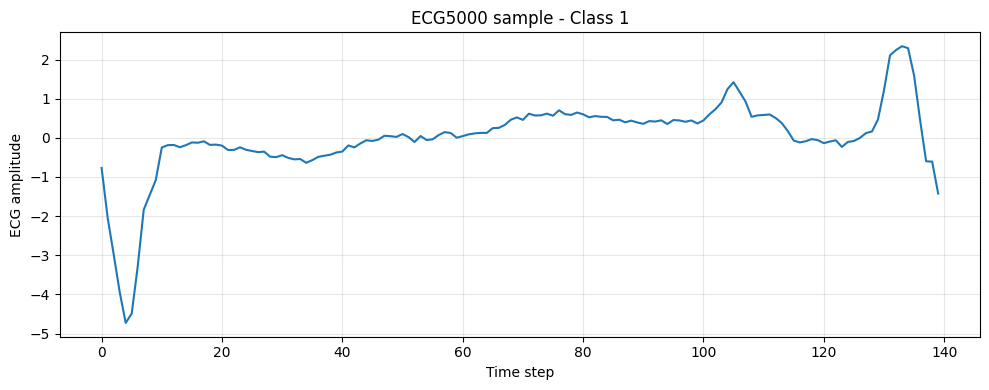

Class counts: [1494  905   50   99   12]
Class weights: tensor([0.5854, 0.7522, 3.2000, 2.2741, 6.5320])
Batch input shape: torch.Size([32, 140, 1])
Batch label shape: torch.Size([32])
Device: cuda

Model: MantisV2FrozenClassifier
Total parameters: 4,189,957
Trainable parameters: 1,285
Learning rate: 0.0001
Epoch   1 | Train Loss: 1.170016 | Val Loss: 1.020221 | Best Val Loss: 1.020221 | Best Epoch: 1
Epoch   2 | Train Loss: 0.924129 | Val Loss: 0.872560 | Best Val Loss: 0.872560 | Best Epoch: 2
Epoch   3 | Train Loss: 0.811947 | Val Loss: 0.794170 | Best Val Loss: 0.794170 | Best Epoch: 3
Epoch   4 | Train Loss: 0.744328 | Val Loss: 0.745628 | Best Val Loss: 0.745628 | Best Epoch: 4
Epoch   5 | Train Loss: 0.699924 | Val Loss: 0.710133 | Best Val Loss: 0.710133 | Best Epoch: 5
Epoch   6 | Train Loss: 0.662998 | Val Loss: 0.682784 | Best Val Loss: 0.682784 | Best Epoch: 6
Epoch   7 | Train Loss: 0.642667 | Val Loss: 0.665489 | Best Val Loss: 0.665489 | Best Epoch: 7
Epoch   8 | Train L

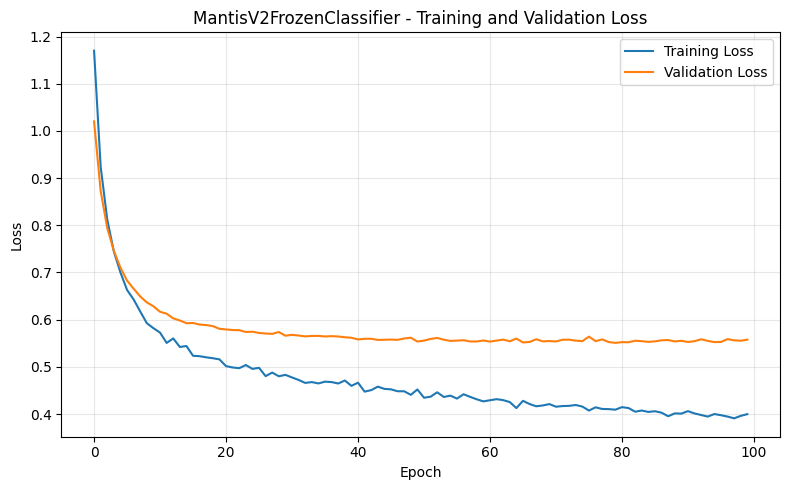


FINAL TEST RESULTS
Model:             MantisV2FrozenClassifier
Accuracy:          93.38%
Balanced Accuracy: 52.62%
Precision (Macro): 0.5885
Recall (Macro):    0.5262
F1 (Macro):        0.5496
Average time/epoch: 1.5783s
Best validation epoch: 80


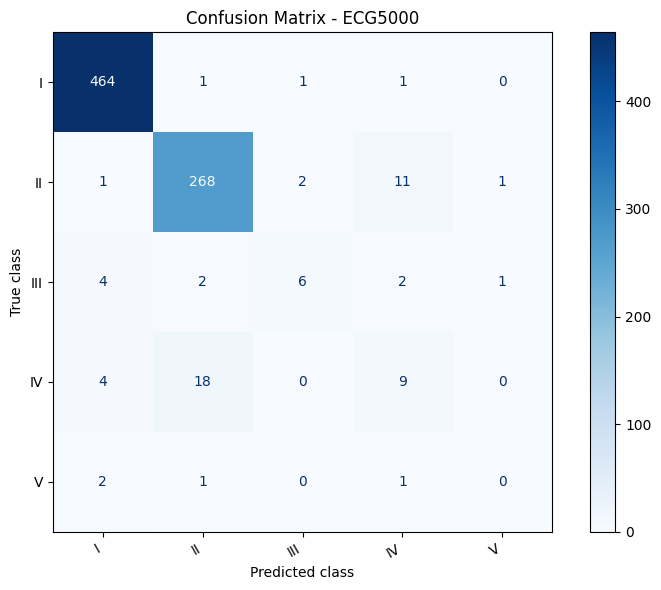

In [ ]:
"""MantisV2 for ECG5000 time-series classification.

ECG5000 setup:
- Development/CV data: ECG5000_CV_4000.txt
- Final untouched test data: ECG5000_FINAL_TEST_1000.txt
- Each ECG has 140 time steps and 1 channel.
- Labels 1..5 in the text files are converted to 0..4 for PyTorch.

Two variants are available:

1) MantisV2FrozenClassifier
   - Pretrained MantisV2 encoder is frozen.
   - Only the classification layer is trained.

2) MantisV2FineTunedClassifier
   - Pretrained MantisV2 encoder is trainable.
   - Encoder and classification layer are trained.
"""

import os
import time

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from torch.utils.data import Dataset, DataLoader
from mantis.architecture import MantisV2


# ============================================================
# PATHS / SETTINGS
# ============================================================

DATA_DIR = "/content/drive/MyDrive/TUBerlin_Data"

TRAIN_PATH = f"{DATA_DIR}/ECG5000_FOLD_4_TRAIN_3200.txt"
TEST_PATH = f"{DATA_DIR}/ECG5000_FOLD_4_VAL_800.txt"
CHECKPOINT_PATH = f"{DATA_DIR}/best_mantis_ecg5000.pth"

NUM_CLASSES = 5
TARGET_LENGTH = 512


# ============================================================
# DATASET
# ============================================================

class ECGDataset(Dataset):
    """ECG5000 dataset.

    Input signal shape per sample:
        (140, 1)

    Label:
        integer from 0 to 4
    """

    def __init__(
        self,
        signals: np.ndarray,
        labels: np.ndarray,
    ):
        self.signals = torch.tensor(
            signals,
            dtype=torch.float32,
        )

        self.labels = torch.tensor(
            labels,
            dtype=torch.long,
        )

    def __len__(self):
        return len(self.signals)

    def __getitem__(self, idx):

        # One complete ECG:
        # (140,) -> (140, 1)
        x = self.signals[idx].unsqueeze(-1)

        # Label is already 0..4
        y = self.labels[idx]

        return x, y


# ============================================================
# MANTISV2 MODELS
# ============================================================

class MantisV2FrozenClassifier(nn.Module):
    """MantisV2 with a frozen pretrained encoder."""

    def __init__(
        self,
        n_classes: int,
        device: torch.device,
        target_length: int = 512,
    ):
        super().__init__()

        self.target_length = target_length

        self.encoder = MantisV2(
            device=str(device),
            return_transf_layer=-1,
            output_token="cls_token",
        )

        self.encoder = self.encoder.from_pretrained(
            "paris-noah/MantisV2"
        )

        # Freeze the pretrained Mantis encoder.
        for parameter in self.encoder.parameters():
            parameter.requires_grad = False

        # MantisV2 CLS-token embedding dimension.
        embedding_dim = self.encoder.hidden_dim

        # ECG5000 is UNIVARIATE:
        # one ECG channel -> one 256-dimensional embedding.
        self.output_projection = nn.Linear(
            embedding_dim,
            n_classes,
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:

        # Dataset / DataLoader input:
        # (B, 140, 1)

        # Conv-style channel-first format:
        # (B, 140, 1) -> (B, 1, 140)
        x = x.transpose(1, 2)

        # Mantis was pretrained using length 512.
        # Resize:
        # (B, 1, 140) -> (B, 1, 512)
        x = F.interpolate(
            x,
            size=self.target_length,
            mode="linear",
            align_corners=False,
        )

        # Keep frozen encoder in evaluation mode even when
        # the outer classifier is in model.train().
        self.encoder.eval()

        with torch.no_grad():
            embeddings = self.encoder(x)

        # embeddings:
        # (B, 256)

        logits = self.output_projection(
            embeddings
        )

        # logits:
        # (B, 5)
        return logits


class MantisV2FineTunedClassifier(nn.Module):
    """MantisV2 with a trainable pretrained encoder."""

    def __init__(
        self,
        n_classes: int,
        device: torch.device,
        target_length: int = 512,
    ):
        super().__init__()

        self.target_length = target_length

        self.encoder = MantisV2(
            device=str(device),
            return_transf_layer=-1,
            output_token="cls_token",
        )

        self.encoder = self.encoder.from_pretrained(
            "paris-noah/MantisV2"
        )

        # Nothing is frozen: gradients can flow through Mantis.
        embedding_dim = self.encoder.hidden_dim

        # One ECG channel -> one Mantis embedding.
        self.output_projection = nn.Linear(
            embedding_dim,
            n_classes,
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:

        # (B, 140, 1) -> (B, 1, 140)
        x = x.transpose(1, 2)

        # (B, 1, 140) -> (B, 1, 512)
        x = F.interpolate(
            x,
            size=self.target_length,
            mode="linear",
            align_corners=False,
        )

        # Gradients ARE enabled here.
        embeddings = self.encoder(x)

        # (B, 256) -> (B, 5)
        logits = self.output_projection(
            embeddings
        )

        return logits


# ============================================================
# PLOTTING
# ============================================================

def plot_sample(
    signals: np.ndarray,
    labels: np.ndarray,
    sample_idx: int = 0,
) -> None:

    signal = signals[sample_idx]
    label = labels[sample_idx] + 1

    plt.figure(figsize=(10, 4))

    plt.plot(
        np.arange(len(signal)),
        signal,
    )

    plt.xlabel("Time step")
    plt.ylabel("ECG amplitude")
    plt.title(
        f"ECG5000 sample - Class {label}"
    )
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(
    true_indices: np.ndarray,
    predicted_indices: np.ndarray,
) -> None:

    class_names = [
        "I",
        "II",
        "III",
        "IV",
        "V",
    ]

    cm = confusion_matrix(
        true_indices,
        predicted_indices,
        labels=np.arange(NUM_CLASSES),
    )

    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names,
    )

    fig, ax = plt.subplots(
        figsize=(8, 6)
    )

    display.plot(
        ax=ax,
        cmap="Blues",
        values_format="d",
    )

    plt.xticks(
        rotation=30,
        ha="right",
    )

    plt.xlabel("Predicted class")
    plt.ylabel("True class")
    plt.title("Confusion Matrix - ECG5000")
    plt.tight_layout()
    plt.show()


# ============================================================
# MAIN
# ============================================================

def main():

    # --------------------------------------------------------
    # 1. Reproducibility
    # --------------------------------------------------------

    torch.manual_seed(42)
    np.random.seed(42)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(42)

    # --------------------------------------------------------
    # 2. Load ECG5000 development/CV data
    # --------------------------------------------------------

    train = pd.read_csv(
        TRAIN_PATH,
        sep=r"\s+",
        header=None,
    )

    # First column = class label.
    # Remaining 140 columns = ECG signal.
    X = train.iloc[:, 1:].values.astype(
        np.float32
    )

    # Convert original labels:
    # 1,2,3,4,5 -> 0,1,2,3,4
    y = (
        train.iloc[:, 0]
        .values
        .astype(np.int64)
        - 1
    )

    print("Full CV data:", X.shape)
    print("Full CV labels:", y.shape)
    print(
        "Classes:",
        np.unique(y),
    )

    # --------------------------------------------------------
    # 3. Training / validation split
    # --------------------------------------------------------

    X_train, X_val, y_train, y_val = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y,
    )

    print(
        "Training:",
        X_train.shape,
        y_train.shape,
    )

    print(
        "Validation:",
        X_val.shape,
        y_val.shape,
    )

    # --------------------------------------------------------
    # 4. Load untouched final test set
    # --------------------------------------------------------

    test = pd.read_csv(
        TEST_PATH,
        sep=r"\s+",
        header=None,
    )

    X_test = test.iloc[:, 1:].values.astype(
        np.float32
    )

    y_test = (
        test.iloc[:, 0]
        .values
        .astype(np.int64)
        - 1
    )

    print(
        "Final test:",
        X_test.shape,
        y_test.shape,
    )

    # Plot one training ECG.
    plot_sample(
        X_train,
        y_train,
        sample_idx=0,
    )

    # --------------------------------------------------------
    # 5. Class weights
    # --------------------------------------------------------
    #
    # ECG5000 is class imbalanced.
    # Use the same square-root weighting approach as the
    # LSTM experiment so the comparison is more controlled.
    #
    # IMPORTANT:
    # We calculate weights using TRAINING DATA ONLY.

    class_counts = np.bincount(
        y_train,
        minlength=NUM_CLASSES,
    )

    class_weights = np.sqrt(
        len(y_train)
        / (NUM_CLASSES * class_counts)
    )

    class_weights = np.clip(
        class_weights,
        a_min=None,
        a_max=10.0,
    )

    class_weights = torch.tensor(
        class_weights,
        dtype=torch.float32,
    )

    print(
        "Class counts:",
        class_counts,
    )

    print(
        "Class weights:",
        class_weights,
    )

    # --------------------------------------------------------
    # 6. Datasets and DataLoaders
    # --------------------------------------------------------

    train_dataset = ECGDataset(
        signals=X_train,
        labels=y_train,
    )

    val_dataset = ECGDataset(
        signals=X_val,
        labels=y_val,
    )

    test_dataset = ECGDataset(
        signals=X_test,
        labels=y_test,
    )

    batch_size = 32

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
    )

    x_batch, y_batch = next(
        iter(train_loader)
    )

    print(
        "Batch input shape:",
        x_batch.shape,
    )

    print(
        "Batch label shape:",
        y_batch.shape,
    )

    # Expected:
    # x_batch = (32, 140, 1)
    # y_batch = (32,)

    # --------------------------------------------------------
    # 7. Device
    # --------------------------------------------------------

    device = torch.device(
        "cuda"
        if torch.cuda.is_available()
        else "cpu"
    )

    print(
        "Device:",
        device,
    )

    # --------------------------------------------------------
    # 8. SELECT MODEL
    # --------------------------------------------------------

    # OPTION 1:
    # Freeze pretrained MantisV2 and train only
    # the final ECG5000 classification layer.
    model_class = MantisV2FrozenClassifier

    # OPTION 2:
    # Fine-tune the full pretrained MantisV2 model.
    # Comment Option 1 and uncomment this line.
    #
    # model_class = MantisV2FineTunedClassifier

    model = model_class(
        n_classes=NUM_CLASSES,
        device=device,
        target_length=TARGET_LENGTH,
    ).to(device)

    model_name = model.__class__.__name__

    print(
        f"\nModel: {model_name}"
    )

    # --------------------------------------------------------
    # 9. Parameter counts
    # --------------------------------------------------------

    total_params = sum(
        parameter.numel()
        for parameter in model.parameters()
    )

    trainable_params = sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

    print(
        f"Total parameters: "
        f"{total_params:,}"
    )

    print(
        f"Trainable parameters: "
        f"{trainable_params:,}"
    )

    # --------------------------------------------------------
    # 10. Loss function
    # --------------------------------------------------------

    class_weights = class_weights.to(
        device
    )

    criterion = nn.CrossEntropyLoss(
        weight=class_weights
    )

    # --------------------------------------------------------
    # 11. Optimizer
    # --------------------------------------------------------

    if model_name == "MantisV2FrozenClassifier":

        learning_rate = 0.0001

        optimizer = torch.optim.Adam(
            filter(
                lambda p: p.requires_grad,
                model.parameters(),
            ),
            lr=learning_rate,
        )

    else:

        # Smaller LR for full pretrained-model fine-tuning.
        learning_rate = 0.00001

        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=learning_rate,
        )

    print(
        "Learning rate:",
        learning_rate,
    )

    # --------------------------------------------------------
    # 12. Training
    # --------------------------------------------------------

    epochs = 100

    train_losses = []
    val_losses = []
    time_per_epoch = []

    best_val_loss = float("inf")
    best_val_epoch = 0

    for epoch in range(epochs):

        start_time = time.time()

        # ---------------- TRAIN ----------------

        model.train()

        train_loss = 0.0

        for x_batch, y_batch in train_loader:

            x_batch = x_batch.to(
                device
            )

            y_batch = y_batch.to(
                device
            )

            optimizer.zero_grad()

            predictions = model(
                x_batch
            )

            loss = criterion(
                predictions,
                y_batch,
            )

            loss.backward()

            # Helps protect against very large gradients,
            # especially when fine-tuning.
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0,
            )

            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(
            train_loader
        )

        train_losses.append(
            train_loss
        )

        # ---------------- VALIDATION ----------------

        model.eval()

        val_loss = 0.0

        with torch.no_grad():

            for x_batch, y_batch in val_loader:

                x_batch = x_batch.to(
                    device
                )

                y_batch = y_batch.to(
                    device
                )

                predictions = model(
                    x_batch
                )

                loss = criterion(
                    predictions,
                    y_batch,
                )

                val_loss += loss.item()

        val_loss /= len(
            val_loader
        )

        val_losses.append(
            val_loss
        )

        epoch_time = (
            time.time()
            - start_time
        )

        time_per_epoch.append(
            epoch_time
        )

        # Save best model based ONLY on validation loss.
        if val_loss < best_val_loss:

            best_val_loss = val_loss
            best_val_epoch = epoch

            torch.save(
                model.state_dict(),
                CHECKPOINT_PATH,
            )

        print(
            f"Epoch {epoch + 1:3d} | "
            f"Train Loss: {train_loss:.6f} | "
            f"Val Loss: {val_loss:.6f} | "
            f"Best Val Loss: {best_val_loss:.6f} | "
            f"Best Epoch: {best_val_epoch + 1}"
        )

    # --------------------------------------------------------
    # 13. Plot training / validation loss
    # --------------------------------------------------------

    plt.figure(
        figsize=(8, 5)
    )

    plt.plot(
        train_losses,
        label="Training Loss",
    )

    plt.plot(
        val_losses,
        label="Validation Loss",
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(
        f"{model_name} - Training and Validation Loss"
    )

    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # 14. Reload BEST validation model
    # --------------------------------------------------------

    best_model = model_class(
        n_classes=NUM_CLASSES,
        device=device,
        target_length=TARGET_LENGTH,
    ).to(device)

    best_model.load_state_dict(
        torch.load(
            CHECKPOINT_PATH,
            map_location=device,
        )
    )

    best_model.eval()

    # --------------------------------------------------------
    # 15. Final test evaluation
    # --------------------------------------------------------

    all_true = []
    all_preds = []

    with torch.no_grad():

        for x_batch, y_batch in test_loader:

            x_batch = x_batch.to(
                device
            )

            outputs = best_model(
                x_batch
            )

            predicted_classes = torch.argmax(
                outputs,
                dim=1,
            )

            all_true.extend(
                y_batch.numpy()
            )

            all_preds.extend(
                predicted_classes
                .cpu()
                .numpy()
            )

    all_true = np.array(
        all_true
    )

    all_preds = np.array(
        all_preds
    )

    # --------------------------------------------------------
    # 16. Metrics
    # --------------------------------------------------------

    accuracy = accuracy_score(
        all_true,
        all_preds,
    )

    balanced_acc = balanced_accuracy_score(
        all_true,
        all_preds,
    )

    precision_macro = precision_score(
        all_true,
        all_preds,
        average="macro",
        zero_division=0,
    )

    recall_macro = recall_score(
        all_true,
        all_preds,
        average="macro",
        zero_division=0,
    )

    f1_macro = f1_score(
        all_true,
        all_preds,
        average="macro",
        zero_division=0,
    )

    print("\n============================")
    print("FINAL TEST RESULTS")
    print("============================")

    print(
        f"Model:             "
        f"{model_name}"
    )

    print(
        f"Accuracy:          "
        f"{accuracy * 100:.2f}%"
    )

    print(
        f"Balanced Accuracy: "
        f"{balanced_acc * 100:.2f}%"
    )

    print(
        f"Precision (Macro): "
        f"{precision_macro:.4f}"
    )

    print(
        f"Recall (Macro):    "
        f"{recall_macro:.4f}"
    )

    print(
        f"F1 (Macro):        "
        f"{f1_macro:.4f}"
    )

    average_time_per_epoch = (
        sum(time_per_epoch)
        / len(time_per_epoch)
    )

    print(
        f"Average time/epoch:"
        f" {average_time_per_epoch:.4f}s"
    )

    print(
        f"Best validation epoch:"
        f" {best_val_epoch + 1}"
    )

    # --------------------------------------------------------
    # 17. Confusion matrix
    # --------------------------------------------------------

    plot_confusion_matrix(
        all_true,
        all_preds,
    )


if __name__ == "__main__":
    main()
